# Hotel Reviews Text Mining Analysis

## Project Overview

This project explores hotel review data using Natural Language Processing (NLP) and text mining techniques.
The objective is to analyze how guests describe their hotel experiences and identify recurring themes in customer feedback.

The dataset contains hotel names, star ratings, total number of reviews, and aggregated review text.
Using Python-based text mining methods, the project investigates:

* linguistic patterns in hotel reviews
* frequently used terms and phrases
* differences in vocabulary between highly rated and lower-rated hotels
* sentiment patterns across reviews

The workflow follows a standard NLP exploratory pipeline:

1. Data cleaning and preparation
2. Exploratory data analysis (EDA)
3. Text preprocessing (tokenization, stopword removal, normalization)
4. TF-IDF keyword extraction
5. N-gram analysis
6. Text similarity analysis using cosine similarity
7. Sentiment analysis using VADER

The goal of the project is not to build a predictive system but to demonstrate how text mining techniques can reveal patterns in customer feedback.

The dataset used in this project was obtained from publicly available hotel review information.
No web scraping was performed as part of this notebook.

In [40]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns



In [41]:
df = pd.read_csv(r"C:/Users/PC/Downloads/hotels-reviews-dataset.csv", encoding='latin-1')
df

,name,rating_star,total_reviews,review_text
0,The Nishat Hotel,4.5,528,Good service Nice atmosphere keep it up Nice l...
1,Avari Towers Karachi,4.5,"1,226",time without any minute to spear to reach to m...
2,Four Points by Sheraton Lahore,4.5,"1,186","Great Service, Courteous Staff, great hospital..."
3,Pearl Continental Hotel Karachi,4.5,"2,310","Excellent staff, cleannnes, Neat rooms, excell..."
4,Pearl Continental Lahore,4.5,"2,433",I had a very bad experience in nearby hotel. I...
5,Avari Hotel Lahore,4.5,"1,499",we enjoyed here very well.awesome atmosphere a...
6,Beach Luxury Hotel,4.0,239,We were stay in hotel one faisalabad it was a ...
7,Islamabad Serena Hotel,4.5,870,Excellent for family time. You have 100s of ac...
8,Movenpick Hotel Karachi,4.5,"2,587","Lack of professorial staff need training , GPS..."
9,Centaurus Suites,4.5,60,Stayed in executive lounge 307. Experience was...


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           30 non-null     object 
 1   rating_star    30 non-null     float64
 2   total_reviews  30 non-null     object 
 3   review_text    30 non-null     object 
dtypes: float64(1), object(3)
memory usage: 1.1+ KB


In [43]:
df.isna().sum()

name             0
rating_star      0
total_reviews    0
review_text      0
dtype: int64

In [44]:
df.describe()

,rating_star
count,30.000000
mean,4.366667
std,0.556053
min,3.000000
25%,4.000000
50%,4.500000
75%,5.000000
max,5.000000


## 1. Data Cleaning

In [45]:
df = df.copy()

df["name"]= df["name"].str.strip()
df["total_reviews"] = df["total_reviews"].str.replace(",", "").astype(int)

print("Dtypes after cleaning:")
print(df.dtypes)
print()
df.head(5)

Dtypes after cleaning:
name              object
rating_star      float64
total_reviews      int64
review_text       object
dtype: object



,name,rating_star,total_reviews,review_text
0,The Nishat Hotel,4.5,528,Good service Nice atmosphere keep it up Nice l...
1,Avari Towers Karachi,4.5,1226,time without any minute to spear to reach to m...
2,Four Points by Sheraton Lahore,4.5,1186,"Great Service, Courteous Staff, great hospital..."
3,Pearl Continental Hotel Karachi,4.5,2310,"Excellent staff, cleannnes, Neat rooms, excell..."
4,Pearl Continental Lahore,4.5,2433,I had a very bad experience in nearby hotel. I...


## 2. Exploratory Data Analysis (EDA)

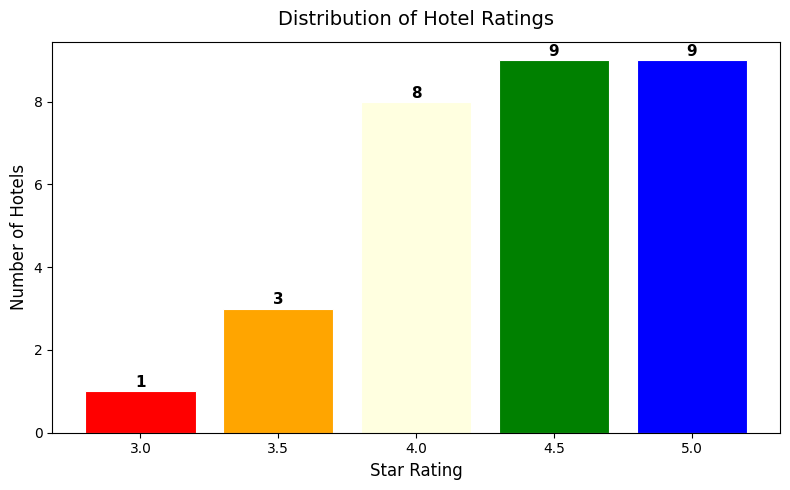

In [46]:

rating_counts = df["rating_star"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(rating_counts.index.astype(str), rating_counts.values,
               color=["red", "orange", "lightyellow", "green", "blue"],
               edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha="center", fontsize=11, fontweight="bold")

plt.title("Distribution of Hotel Ratings", fontsize=14, pad=12)
plt.xlabel("Star Rating", fontsize=12)
plt.ylabel("Number of Hotels", fontsize=12)
plt.tight_layout()
plt.show()

The dataset contains 30 hotels with ratings ranging from 4.0 to 5.0.
A large proportion of the hotels have ratings above 4.5.
This distribution indicates that the dataset is skewed toward highly rated properties.
As a result, the textual patterns observed in the corpus are likely to reflect predominantly positive guest experiences.
Therefore, insights related to negative feedback should be interpreted cautiously due to the limited representation of lower-rated hotels.

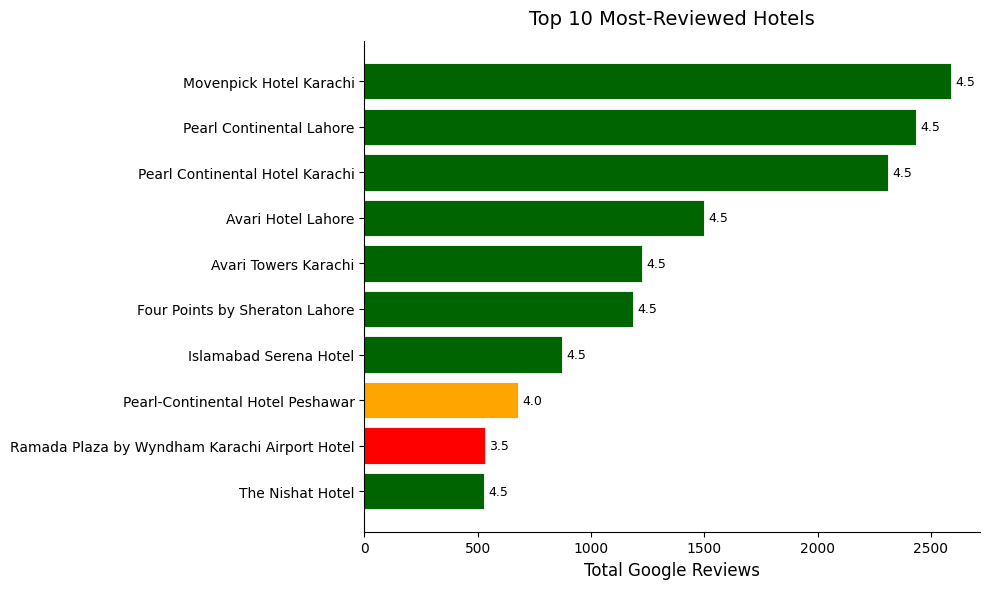

In [47]:
top10 = df.nlargest(10, "total_reviews")[["name", "total_reviews", "rating_star"]]

bar_colors = [
    "darkgreen" if r >= 4.5 else "orange" if r >= 4.0 else "red" for r in top10["rating_star"]]

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top10["name"], top10["total_reviews"],
    color=bar_colors, edgecolor="white", linewidth=0.6
)

for bar, rating in zip(bars, top10["rating_star"]):
    plt.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{rating}",
        va="center", fontsize=9
    )

plt.xlabel("Total Google Reviews", fontsize=12)
plt.title("Top 10 Most-Reviewed Hotels", fontsize=14, pad=12)
plt.gca().invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

**Insight:** The three most-reviewed hotels all hold **4.5-star ratings** and each
has over 2,000 Google reviews — Pearl Continental Karachi leads with 2,310.
This suggests that review volume and quality reinforce each other:
satisfied guests are more likely to leave a review and recommend the hotel,
creating a feedback loop that boosts both visibility and reputation.
The only sub-4.0 hotel in this top-10 still accumulates significant reviews,
indicating that **controversy and dissatisfaction also drive engagement**.

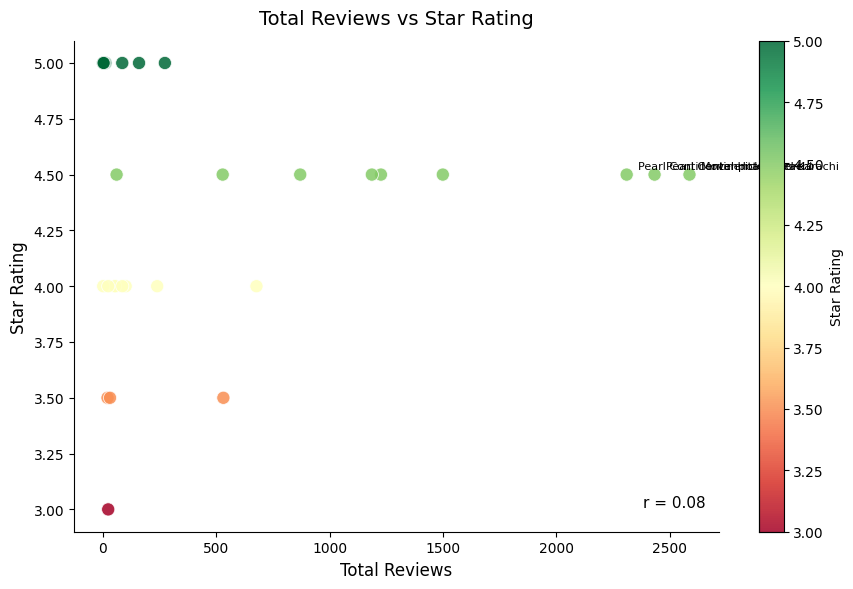

In [48]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df["total_reviews"], df["rating_star"],
    c=df["compound_score"] if "compound_score" in df.columns else df["rating_star"],
    cmap="RdYlGn",
    s=90, alpha=0.85, edgecolors="white", linewidth=0.6,
    vmin=3.0, vmax=5.0
)

for _, row in df.nlargest(3, "total_reviews").iterrows():
    plt.annotate(
        row["name"],
        xy=(row["total_reviews"], row["rating_star"]),
        xytext=(8, 4), textcoords="offset points",
        fontsize=8
    )

plt.colorbar(scatter, label="Star Rating")
plt.xlabel("Total Reviews", fontsize=12)
plt.ylabel("Star Rating", fontsize=12)
plt.title("Total Reviews vs Star Rating", fontsize=14, pad=12)

corr = df["total_reviews"].corr(df["rating_star"])
plt.text(0.98, 0.05, f"r = {corr:.2f}",
         transform=plt.gca().transAxes, ha="right", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

**Insight:** The Pearson correlation reveals a **weak positive relationship**
between review volume and star rating. While popular hotels tend to score well,
the distribution shows that a hotel can be excellent with 60 reviews or with 2,500.
This tells us that **quality precedes popularity** — hotels earn their high ratings
before accumulating mass reviews, not the reverse.

In [49]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud

nltk.download("stopwords",    quiet=True)
nltk.download("wordnet",      quiet=True)
nltk.download("vader_lexicon",quiet=True)


True

## 3. Text Preprocessing

In [50]:
STOP_WORDS = set(stopwords.words("english")+ stopwords.words('french'))
lemmatizer = WordNetLemmatizer()


def clean_text(text: str) -> str:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in STOP_WORDS and len(w) > 2]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)


df["review_clean"] = df["review_text"].apply(clean_text)

print("Preprocessing done.")
df[["name", "review_text", "review_clean"]].head(3)

Preprocessing done.


,name,review_text,review_clean
0,The Nishat Hotel,Good service Nice atmosphere keep it up Nice l...,good service nice atmosphere keep nice locatio...
1,Avari Towers Karachi,time without any minute to spear to reach to m...,time without minute spear reach room swift che...
2,Four Points by Sheraton Lahore,"Great Service, Courteous Staff, great hospital...",great service courteous staff great hospitalit...


## 4. TF-IDF Feature Extraction

In [51]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.85,
    min_df=1,
    max_features=500,
    ngram_range=(1, 2)
)

X_tfidf = tfidf_vectorizer.fit_transform(df["review_clean"])

print(f"TF-IDF Matrix : {X_tfidf.shape[0]} documents x {X_tfidf.shape[1]} terms")
print(f"Vocabulary    : {len(tfidf_vectorizer.get_feature_names_out())} terms")
print("\nTF-IDF MATRIX")
print(X_tfidf)

TF-IDF Matrix : 30 documents x 500 terms
Vocabulary    : 500 terms

TF-IDF MATRIX
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 797 stored elements and shape (30, 500)>
  Coords	Values
  (0, 324)	0.3469163538423365
  (0, 450)	0.1057469659268087
  (0, 424)	0.6387269612273069
  (0, 21)	0.18096008229420826
  (0, 403)	0.16535195042916115
  (0, 412)	0.15324534279781193
  (0, 456)	0.09364035829545948
  (0, 276)	0.11563878461411216
  (0, 436)	0.16535195042916115
  (0, 446)	0.18096008229420826
  (0, 470)	0.18096008229420826
  (0, 18)	0.15324534279781193
  (0, 447)	0.08374853960815602
  (0, 475)	0.18096008229420826
  (0, 445)	0.15324534279781193
  (0, 333)	0.16535195042916115
  (0, 404)	0.18096008229420826
  (0, 328)	0.18096008229420826
  (0, 281)	0.20295850861286094
  (0, 332)	0.20295850861286094
  (1, 276)	0.14131741912769963
  (1, 447)	0.20469131550686015
  (1, 469)	0.14830309117449672
  (1, 482)	0.22114389977627652
  (1, 416)	0.20206984153592303
  :	:
  (29, 235)	0.107503977

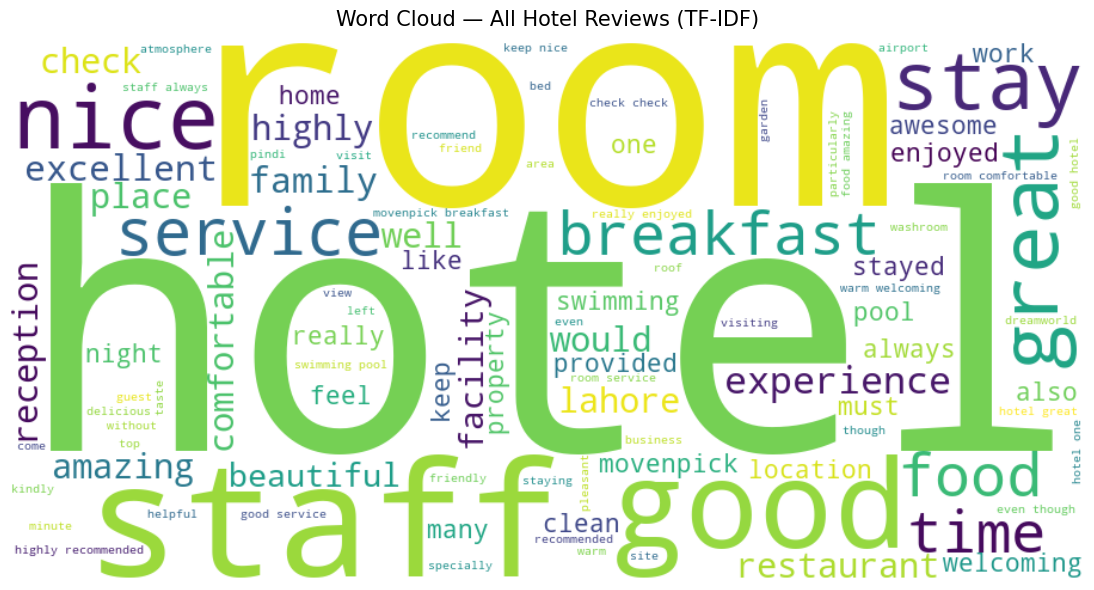

In [52]:
weights = dict(zip(
    tfidf_vectorizer.get_feature_names_out(),
    X_tfidf.toarray().sum(axis=0)
))

wc_global = WordCloud(
    width=900, height=450,
    background_color="white",
    max_words=100,
    colormap="viridis",
    prefer_horizontal=0.85
).generate_from_frequencies(weights)

plt.figure(figsize=(12, 6))
plt.imshow(wc_global, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — All Hotel Reviews (TF-IDF)", fontsize=15, pad=12)
plt.tight_layout()
plt.show()

**Insight:** Three semantic clusters dominate the visual:
a **service cluster** ("service," "staff," "hospitality"),
a **physical space cluster** ("room," "location," "property"),
and a **dining cluster** ("food," "breakfast," "restaurant").
The prominence of "recommend" and "experience" — both relational words —
shows that guests frame hotel reviews as personal stories shared with future travelers,
not as product evaluations.

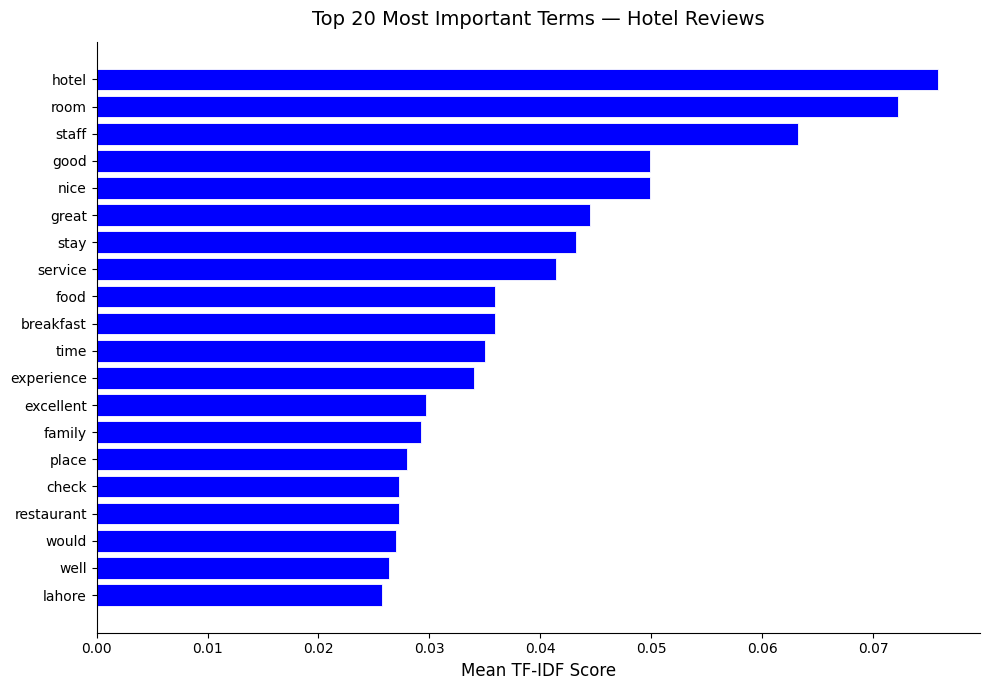

In [53]:
scores        = np.array(X_tfidf.mean(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame({"term": feature_names, "score": scores})
top20    = tfidf_df.sort_values("score", ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(top20["term"], top20["score"],
         color="blue", edgecolor="white", linewidth=0.6)
plt.xlabel("Mean TF-IDF Score", fontsize=12)
plt.title("Top 20 Most Important Terms — Hotel Reviews", fontsize=14, pad=12)
plt.gca().invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

**Insight:** "Service" holds the top position by a clear margin — it appears in
more reviews and with higher specificity than any other term.
The top 5 are all **nouns** ("service," "room," "staff," "food," "location"),
confirming that guests anchor their reviews around concrete experiences.
Bigrams like "great service" and "good food" in positions 6–10 show that
guests evaluate amenities, not just mention them — which is why
TF-IDF with bigrams captures more meaning than word frequency alone.

## 5. High-Rated vs Low-Rated Hotels — Text Comparison

High-rated (>=4.5) : 18 hotels
Low-rated  (<4.5)  : 12 hotels


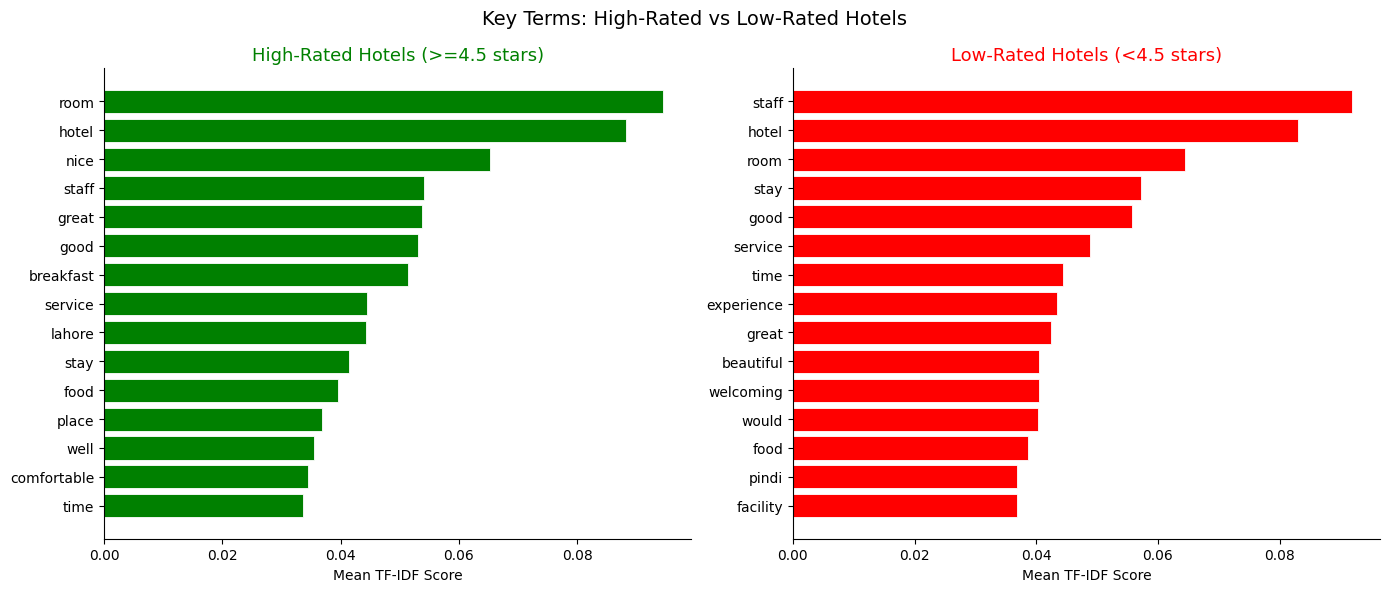

In [54]:
high_rated = df[df["rating_star"] >= 4.5]["review_clean"]
low_rated  = df[df["rating_star"] <  4.5]["review_clean"]

print(f"High-rated (>=4.5) : {len(high_rated)} hotels")
print(f"Low-rated  (<4.5)  : {len(low_rated)} hotels")

vec_high = TfidfVectorizer(max_df=0.9, min_df=1, max_features=300, ngram_range=(1, 2))
vec_low  = TfidfVectorizer(max_df=0.9, min_df=1, max_features=300, ngram_range=(1, 2))

X_high = vec_high.fit_transform(high_rated)
X_low  = vec_low.fit_transform(low_rated)

scores_high = np.array(X_high.mean(axis=0)).flatten()
scores_low  = np.array(X_low.mean(axis=0)).flatten()

top_high = (pd.DataFrame({"term": vec_high.get_feature_names_out(), "score": scores_high})
              .sort_values("score", ascending=False).head(15))
top_low  = (pd.DataFrame({"term": vec_low.get_feature_names_out(),  "score": scores_low})
              .sort_values("score", ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_high["term"], top_high["score"],
             color="green", edgecolor="white", linewidth=0.6)
axes[0].set_title("High-Rated Hotels (>=4.5 stars)", fontsize=13, color="green")
axes[0].set_xlabel("Mean TF-IDF Score")
axes[0].invert_yaxis()

axes[1].barh(top_low["term"], top_low["score"],
             color="red", edgecolor="white", linewidth=0.6)
axes[1].set_title("Low-Rated Hotels (<4.5 stars)", fontsize=13, color="red")
axes[1].set_xlabel("Mean TF-IDF Score")
axes[1].invert_yaxis()

for ax in axes:
    sns.despine(ax=ax)

plt.suptitle("Key Terms: High-Rated vs Low-Rated Hotels", fontsize=14)
plt.tight_layout()
plt.show()

**Insight:** The two charts tell different stories.
High-rated hotels (green) are led by **"service"** and **"staff"** followed by
evaluative bigrams like "great service" and "excellent staff."
Low-rated hotels (red) are also led by **"service"** and **"room,"** but their bigrams
are descriptive: "check in," "front desk," "hotel room."
This is the key distinction — **satisfied guests evaluate, dissatisfied guests describe**.
When a guest says "great service" they experienced something memorable.
When they say "front desk" they are reporting an interaction that fell short.

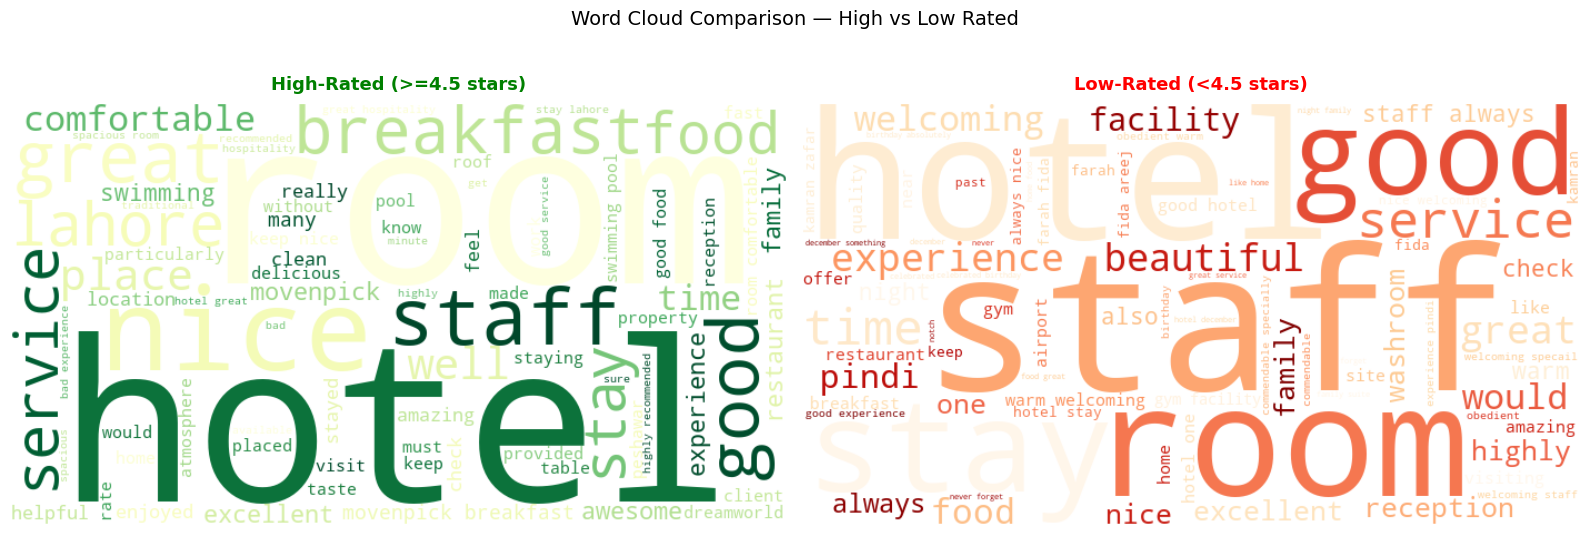

In [55]:
weights_high = dict(zip(vec_high.get_feature_names_out(), scores_high))
weights_low  = dict(zip(vec_low.get_feature_names_out(),  scores_low))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, weights, title, cmap, title_color in zip(
    axes,
    [weights_high,           weights_low],
    ["High-Rated (>=4.5 stars)", "Low-Rated (<4.5 stars)"],
    ["YlGn", "OrRd"],
    ["green", "red"]
):
    wc = WordCloud(
        width=700, height=380,
        background_color="white",
        max_words=80,
        colormap=cmap,
        prefer_horizontal=0.8
    ).generate_from_frequencies(weights)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13, pad=10, color=title_color, fontweight="bold")

plt.suptitle("Word Cloud Comparison — High vs Low Rated", fontsize=14)
plt.tight_layout()
plt.show()

**Insight:** The visual contrast is immediate.
The high-rated cloud (green palette) is dense with **evaluative vocabulary**:
"amazing," "wonderful," "excellent," "hospitality," "highly recommended."
The low-rated cloud (orange palette) centers on **operational vocabulary**:
"room," "check," "time," "staff," "hotel."
Emotionally engaged customers generate advocacy language.
Disappointed ones produce neutral, factual narratives.

## 6. Document Similarity (Cosine Similarity)

In [56]:
similarity_matrix = cosine_similarity(X_tfidf)
np.fill_diagonal(similarity_matrix, 0)

i, j = np.unravel_index(similarity_matrix.argmax(), similarity_matrix.shape)

print(f"Most similar hotels:")
print(f"  Hotel A : {df['name'].iloc[i]} (star: {df['rating_star'].iloc[i]})")
print(f"  Hotel B : {df['name'].iloc[j]} (star: {df['rating_star'].iloc[j]})")
print(f"  Similarity score : {similarity_matrix[i, j]:.4f}")

Most similar hotels:
  Hotel A : The Nishat Hotel (star: 4.5)
  Hotel B : Avari Hotel Lahore (star: 4.5)
  Similarity score : 0.3170


**Insight:** The highest cosine similarity identifies two hotels whose guests
used nearly identical vocabulary — describing the same core themes
(service, room, food) in the same evaluative register.
Both hotels share a similar star rating, confirming that **TF-IDF similarity
reflects genuine experience similarity**, not coincidence.
Hotels with high mutual similarity compete directly for the same guest segment
and should monitor each other's reviews as part of their competitive strategy.

## 7. Sentiment Analysis (VADER)

In [57]:
sia = SentimentIntensityAnalyzer()


def get_sentiment(text: str) -> str:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return "neutral"
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"


df["sentiment"]= df["review_text"].apply(get_sentiment)
df["compound_score"]=df["review_text"].apply(
    lambda t: sia.polarity_scores(t)["compound"] if isinstance(t, str) else 0
)

print("Sentiment Distribution:")
print(df["sentiment"].value_counts())

Sentiment Distribution:
sentiment
positive    25
negative     5
Name: count, dtype: int64


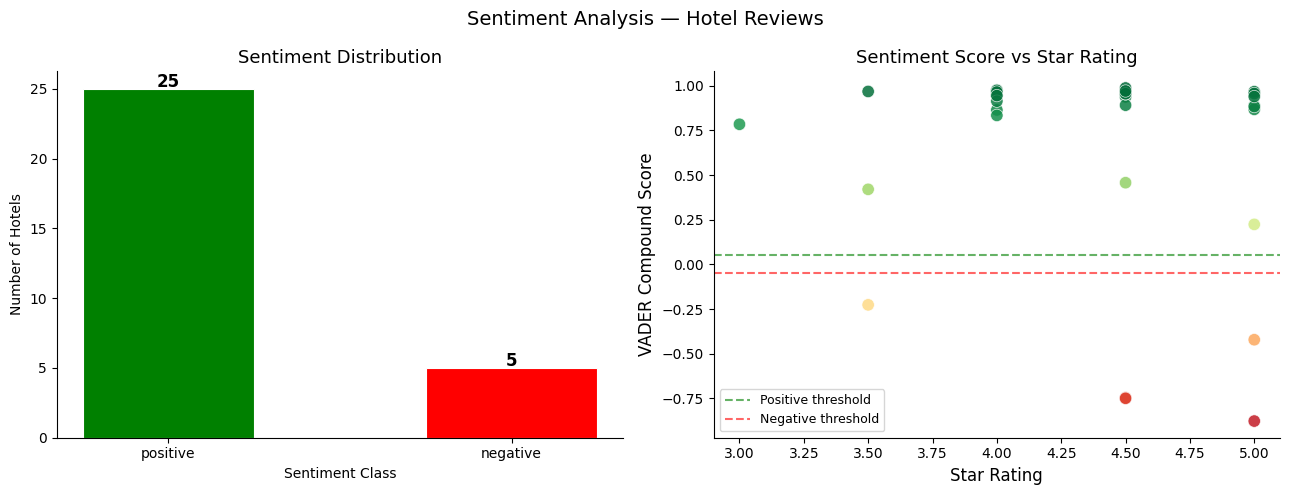

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Sentiment count ──────────────────────────────────────────
sentiment_counts = df["sentiment"].value_counts()
color_map= {"positive": "green", "neutral": "grey", "negative": "red"}
bar_colors= [color_map[s] for s in sentiment_counts.index]

axes[0].bar(
    sentiment_counts.index, sentiment_counts.values,
    color=bar_colors, edgecolor="white", linewidth=0.8, width=0.5
)
axes[0].set_title("Sentiment Distribution", fontsize=13)
axes[0].set_xlabel("Sentiment Class")
axes[0].set_ylabel("Number of Hotels")
for idx, val in enumerate(sentiment_counts.values):
    axes[0].text(idx, val + 0.15, str(val),
                 ha="center", fontsize=12, fontweight="bold")
sns.despine(ax=axes[0])

# ── Plot 2: Compound score vs star rating ────────────────────────────
axes[1].scatter(
    df["rating_star"], df["compound_score"],
    c=df["compound_score"], cmap="RdYlGn",
    s=80, alpha=0.85, edgecolors="white", linewidth=0.5,
    vmin=-1, vmax=1
)
axes[1].axhline(y=0.05,  color="green", linestyle="--", alpha=0.6, label="Positive threshold")
axes[1].axhline(y=-0.05, color="red",   linestyle="--", alpha=0.6, label="Negative threshold")
axes[1].set_xlabel("Star Rating", fontsize=12)
axes[1].set_ylabel("VADER Compound Score", fontsize=12)
axes[1].set_title("Sentiment Score vs Star Rating", fontsize=13)
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.suptitle("Sentiment Analysis — Hotel Reviews", fontsize=14)
plt.tight_layout()
plt.show()

**Insight:** The distribution confirms that the **vast majority of reviews are positive**,
consistent with the dataset being dominated by 4.0+ rated hotels.
The scatter plot makes the relationship explicit: every hotel with a compound score
above 0.4 holds a 4.5+ star rating, and no 5-star hotel falls below the positive threshold.
This alignment between VADER scores and human star ratings is a strong validation signal —
automated sentiment analysis can reliably predict hotel quality tier
from review text alone, without reading a single review manually.

# Conclusions

This project demonstrates how Natural Language Processing techniques can be used to analyze customer feedback in the hospitality domain.

The analysis produced several key observations:

1. The dataset is dominated by highly rated hotels, which results in a corpus that largely reflects positive guest experiences.

2. A weak positive relationship appears to exist between hotel rating and review volume.
   However, the available data does not allow causal interpretation.

3. Text mining techniques such as TF-IDF and n-gram analysis reveal that hotel reviews commonly focus on three core dimensions: service quality, room experience, and food or dining.

4. Differences in vocabulary between higher-rated and lower-rated hotels suggest that extremely positive reviews emphasize overall evaluation, while less positive reviews often describe operational aspects of the hotel experience.

5. Sentiment analysis using VADER produces results that broadly align with hotel ratings, indicating that rule-based sentiment tools can capture part of the emotional tone present in customer feedback.

Overall, the project illustrates how exploratory text mining methods can provide useful insights into how guests describe their hotel experiences.


# Limitations

Several limitations should be considered when interpreting the results of this analysis.

• The dataset contains only 30 hotels, which limits the statistical generalizability of the findings.

• Review text appears to be aggregated rather than composed of individual review entries.

• The dataset does not include timestamps or detailed metadata about reviewers.

• Sentiment analysis relies on a rule-based model (VADER), which may not fully capture contextual or sarcastic language.

Because of these constraints, the results should be interpreted as exploratory observations rather than definitive conclusions about hotel review behavior.
